# Spectral vs Embedding Similarity

This notebook compares two different notions of similarity for pairs of AlphaEarth locations:

1. **Spectral similarity** — dot product of true-color (RGB) pixel patches sampled from the AlphaEarth RGB GeoTIFFs. This is a proxy for *visual* resemblance: do the two places look alike to the eye?
2. **Embedding similarity** — cosine similarity of the 64-dimensional AlphaEarth Foundation embeddings. This captures *ontological* resemblance: does the model consider the places semantically alike?

We search for two types of outliers:
- **Visually similar, ontologically different**: high spectral dot product, low embedding cosine similarity
- **Visually dissimilar, ontologically similar**: low spectral dot product, high embedding cosine similarity

For the best example of each type, we save satellite image patches and false-color embedding visualizations to subdirectories.

In [10]:
import base64
import json
import os
import warnings
import numpy as np
import geopandas as gpd
import rasterio
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial.distance import cosine
import requests
from PIL import Image
from io import BytesIO
import ee

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "Courier New"

# ── paths ──────────────────────────────────────────────────────────────────────
GEOJSON = "../dimension-reduction/data/5000_sampled_classified_embeddings.geojson"
RGB_PARTS = [
    "../web-maps/webmap-data-prep/alphaearth_2024_rgb_part0.tif",
    "../web-maps/webmap-data-prep/alphaearth_2024_rgb_part1.tif",
    "../web-maps/webmap-data-prep/alphaearth_2024_rgb_part2.tif",
    "../web-maps/webmap-data-prep/alphaearth_2024_rgb_part3.tif",
]
OUTPUT_DIR = "spectral_distance_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── initialize Earth Engine ────────────────────────────────────────────────────
try:
    ee.Initialize(project="gsapp-map")
    print("Earth Engine initialized.")
except Exception:
    ee.Authenticate()
    ee.Initialize(project="gsapp-map")
    print("Earth Engine authenticated and initialized.")

# ── load embeddings ────────────────────────────────────────────────────────────
gdf = gpd.read_file(GEOJSON)
gdf["embedding"] = gdf["embedding"].apply(lambda v: np.array(json.loads(base64.b64decode(v))))
gdf["lat"] = gdf["lat"].astype(float)
gdf["lon"] = gdf["lon"].astype(float)

print(f"Loaded {len(gdf)} features")
print(f"Embedding dim: {len(gdf['embedding'].iloc[0])}")


Earth Engine initialized.
Loaded 5000 features
Embedding dim: 64


## Step 1: Build a Spectral Sampler

We open the four AlphaEarth RGB GeoTIFFs (which together span the globe) and define a helper that, given a lat/lon, returns a small normalized pixel patch. The dot product of two flattened, L2-normalized patches gives a spectral similarity score in `[-1, 1]`.

In [11]:
# Open all four RGB parts once and keep them in memory
rgb_datasets = [rasterio.open(p) for p in RGB_PARTS]

PATCH_PX = 5   # half-size: extract a (2*PATCH_PX+1)^2 patch
PATCH_FULL = 2 * PATCH_PX + 1  # full side length: 11 pixels

def sample_rgb_patch(lat, lon, patch_px=PATCH_PX):
    """
    Sample a (2*patch_px+1) x (2*patch_px+1) RGB patch from the RGB GeoTIFFs
    at the given lat/lon.  Returns a flattened, L2-normalised float32 vector
    of fixed length (3 * full * full), or None if the location falls in a
    no-data region.  Edge patches are zero-padded to the full size so that
    all vectors have the same dimensionality.
    """
    full = 2 * patch_px + 1
    for ds in rgb_datasets:
        b = ds.bounds
        if b.left <= lon <= b.right and b.bottom <= lat <= b.top:
            row, col = ds.index(lon, lat)
            h, w = ds.shape
            r0 = max(0, row - patch_px)
            c0 = max(0, col - patch_px)
            r1 = min(h, row + patch_px + 1)
            c1 = min(w, col + patch_px + 1)
            win = rasterio.windows.Window(c0, r0, c1 - c0, r1 - r0)
            patch = ds.read(window=win).astype(np.float32)  # (3, H', W')
            if np.isnan(patch).all():
                continue
            patch = np.nan_to_num(patch, nan=0.0)

            # Zero-pad to (3, full, full) so all vectors are the same size.
            # dr/dc = offset into the padded array where the clipped patch starts.
            # The intended top-left in dataset space is (row-patch_px, col-patch_px);
            # r0/c0 are clamped to >=0, so the offset inside the padded array is
            # r0-(row-patch_px) and c0-(col-patch_px) (always >= 0).
            _, ph, pw = patch.shape
            if ph != full or pw != full:
                padded = np.zeros((3, full, full), dtype=np.float32)
                dr = r0 - (row - patch_px)
                dc = c0 - (col - patch_px)
                padded[:, dr:dr + ph, dc:dc + pw] = patch
                patch = padded

            vec = patch.flatten()
            norm = np.linalg.norm(vec)
            if norm < 1e-9:
                continue
            return vec / norm
    return None

def spectral_similarity(lat1, lon1, lat2, lon2):
    """Dot product of normalised RGB patches (≈ cosine similarity)."""
    v1 = sample_rgb_patch(lat1, lon1)
    v2 = sample_rgb_patch(lat2, lon2)
    if v1 is None or v2 is None:
        return np.nan
    return float(np.dot(v1, v2))

def embedding_similarity(emb1, emb2):
    """Cosine similarity of two embedding vectors."""
    return float(1 - cosine(emb1, emb2))

# Quick sanity check
print("Spectral sampler ready.")
test_patch = sample_rgb_patch(48.8, 2.3)  # Paris
print(f"Paris patch vector length: {len(test_patch) if test_patch is not None else 'None'}")
print(f"Expected: {3 * PATCH_FULL * PATCH_FULL}")


Spectral sampler ready.
Paris patch vector length: 363
Expected: 363


## Step 2: Compute Spectral & Embedding Similarities for Sampled Pairs

We draw a random sample of location pairs from the GeoJSON, compute both similarity scores, and scatter-plot the joint distribution. The axes are:
- **x**: spectral similarity (RGB dot product)
- **y**: embedding cosine similarity

Outliers in the top-left quadrant are **visually similar but ontologically different**.  
Outliers in the bottom-right quadrant are **visually dissimilar but ontologically similar**.

In [12]:
import time as _time

np.random.seed(42)
N_LOCS  = 200   # each location = one GEE call; ~200 takes 3–5 min
N_PAIRS = 5000

# CGLS-LC100 class names (Copernicus Global Land Service 100 m Land Cover)
LC_NAMES = {
    0:   "Ocean / no-data",
    20:  "Shrubland",
    30:  "Grassland",
    40:  "Cropland",
    50:  "Built-up",
    60:  "Bare / sparse vegetation",
    70:  "Snow and ice",
    80:  "Permanent water",
    90:  "Herbaceous wetland",
    100: "Moss / lichen",
    111: "Closed forest – evergreen needle",
    112: "Closed forest – evergreen broadleaf",
    113: "Closed forest – deciduous needle",
    114: "Closed forest – deciduous broadleaf",
    115: "Closed forest – mixed",
    116: "Closed forest – unknown",
    121: "Open forest – evergreen needle",
    122: "Open forest – evergreen broadleaf",
    124: "Open forest – deciduous broadleaf",
    125: "Open forest – mixed",
    126: "Open forest – unknown",
}

loc_idx = np.random.choice(len(gdf), N_LOCS, replace=False)
locs    = gdf.iloc[loc_idx].reset_index(drop=True)

# ── Sentinel-2 spectral comparison ────────────────────────────────────────────
# APPROACH: compare the MEAN spectral signature (3-band average) per patch.
# We average all pixels per band → L2-normalise the 3-element vector → dot product.
# This asks "do these two places have the same dominant spectral character?"
# and is rotation- / translation-invariant. Pixel-level flat-vector comparison
# was spatially sensitive (two identical deserts with slightly different texture
# could score low), explaining why "similar" pairs looked different.
#
# Window: 64 px × 10 m/px = 640 m square, matching AlphaEarth's embedding footprint.

SAT_YEAR       = 2024
SAT_CMP_PX     = 64    # pixels per side (matches AlphaEarth 64-px tile)
SAT_CMP_SCALE  = 10    # metres/pixel (native Sentinel-2)
SAT_CMP_BUFFER = SAT_CMP_SCALE * SAT_CMP_PX / 2  # = 320 m half-width → 640 m square

_s2_coll = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")

def fetch_s2_entry(lat, lon):
    """
    Download a SAT_CMP_PX × SAT_CMP_PX Sentinel-2 RGB patch from GEE.
    Returns a dict {"sig": 3-element L2-normalised mean-RGB vector,
                    "img": (H,W,3) uint8 array for display}
    or None on failure.

    SPECTRAL METRIC: mean per band (R̄, Ḡ, B̄), then cosine similarity.
    This is invariant to pixel spatial layout — it captures the dominant
    colour character of the 640 m footprint.
    """
    point  = ee.Geometry.Point(lon, lat)
    region = point.buffer(SAT_CMP_BUFFER).bounds()
    for cloud_thresh in [20, 50, 101]:
        try:
            col = (_s2_coll
                   .filterDate(f"{SAT_YEAR}-01-01", f"{SAT_YEAR+1}-01-01")
                   .filterBounds(region))
            if cloud_thresh <= 100:
                col = col.filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", cloud_thresh))
            img_ee = col.median().select(["B4", "B3", "B2"])
            url = img_ee.getThumbURL({
                "region": region,
                "dimensions": f"{SAT_CMP_PX}x{SAT_CMP_PX}",
                "format": "png",
                "min": 0, "max": 3000,
            })
            resp = requests.get(url, timeout=60)
            if resp.status_code == 200:
                arr = np.array(Image.open(BytesIO(resp.content)).convert("RGB")).astype(np.float32)
                # Mean spectral signature: average all pixels per band → (3,)
                mean_rgb = arr.mean(axis=(0, 1))
                norm = np.linalg.norm(mean_rgb)
                if norm > 1e-9:
                    return {"sig": mean_rgb / norm, "img": arr.astype(np.uint8)}
        except Exception:
            continue
    return None

# ── pre-fetch one patch per location ──────────────────────────────────────────
print(f"Pre-fetching {SAT_CMP_PX}×{SAT_CMP_PX} px Sentinel-2 patches for {N_LOCS} locations")
print(f"  Resolution : {SAT_CMP_SCALE} m/px")
print(f"  Window     : {SAT_CMP_PX*SAT_CMP_SCALE} m × {SAT_CMP_PX*SAT_CMP_SCALE} m (AlphaEarth footprint)")
print(f"  Metric     : cosine similarity of mean R/G/B per patch (layout-invariant)\n")
t0 = _time.time()
s2_cache = {}   # idx → {"sig": ndarray(3), "img": ndarray(H,W,3)}
for _i, _row in locs.iterrows():
    s2_cache[_i] = fetch_s2_entry(_row["lat"], _row["lon"])
    if (_i + 1) % 20 == 0 or _i == N_LOCS - 1:
        n_ok = sum(v is not None for v in s2_cache.values())
        print(f"  {_i+1:3d}/{N_LOCS}  ({n_ok} ok)  {_time.time()-t0:.0f}s")

n_ok = sum(v is not None for v in s2_cache.values())
print(f"\nFetched {n_ok}/{N_LOCS} patches  ({_time.time()-t0:.0f}s total)")

# ── compute pair similarities ──────────────────────────────────────────────────
upper_i, upper_j = np.triu_indices(N_LOCS, k=1)
pair_idx = np.random.choice(len(upper_i), min(N_PAIRS, len(upper_i)), replace=False)

results = []
print(f"\nComputing similarities for {len(pair_idx)} pairs across {N_LOCS} locations …")
for k, pidx in enumerate(pair_idx):
    i, j = int(upper_i[pidx]), int(upper_j[pidx])
    row_i, row_j = locs.iloc[i], locs.iloc[j]

    ei, ej = s2_cache.get(i), s2_cache.get(j)
    if ei is None or ej is None:
        continue

    # cosine sim of mean spectral signatures
    spec_sim = float(np.dot(ei["sig"], ej["sig"]))
    emb_sim  = embedding_similarity(row_i["embedding"], row_j["embedding"])

    results.append({
        "i": i, "j": j,
        "lat_i": row_i["lat"], "lon_i": row_i["lon"],
        "lat_j": row_j["lat"], "lon_j": row_j["lon"],
        "class_i": row_i["classification"],
        "class_j": row_j["classification"],
        "lc_i": LC_NAMES.get(row_i["classification"], str(row_i["classification"])),
        "lc_j": LC_NAMES.get(row_j["classification"], str(row_j["classification"])),
        "region_i": row_i["subregion_name"],
        "region_j": row_j["subregion_name"],
        "spec_sim": spec_sim,
        "emb_sim":  emb_sim,
    })
    if (k + 1) % 1000 == 0:
        print(f"  {k+1}/{len(pair_idx)} …")

print(f"\nValid pairs: {len(results)}")
spec_arr = np.array([r["spec_sim"] for r in results])
emb_arr  = np.array([r["emb_sim"]  for r in results])
print(f"Spectral sim  — min: {spec_arr.min():.3f}, max: {spec_arr.max():.3f}, mean: {spec_arr.mean():.3f}")
print(f"Embedding sim — min: {emb_arr.min():.3f},  max: {emb_arr.max():.3f},  mean: {emb_arr.mean():.3f}")


Pre-fetching 64×64 px Sentinel-2 patches for 200 locations
  Resolution : 10 m/px
  Window     : 640 m × 640 m (AlphaEarth footprint)
  Metric     : cosine similarity of mean R/G/B per patch (layout-invariant)

   20/200  (20 ok)  34s
   40/200  (40 ok)  64s
   60/200  (60 ok)  97s
   80/200  (80 ok)  126s
  100/200  (100 ok)  157s
  120/200  (120 ok)  184s
  140/200  (140 ok)  218s
  160/200  (160 ok)  258s
  180/200  (180 ok)  291s
  200/200  (200 ok)  329s

Fetched 200/200 patches  (329s total)

Computing similarities for 5000 pairs across 200 locations …
  1000/5000 …
  2000/5000 …
  3000/5000 …
  4000/5000 …
  5000/5000 …

Valid pairs: 5000
Spectral sim  — min: 0.669, max: 1.000, mean: 0.969
Embedding sim — min: -0.243,  max: 0.992,  mean: 0.121


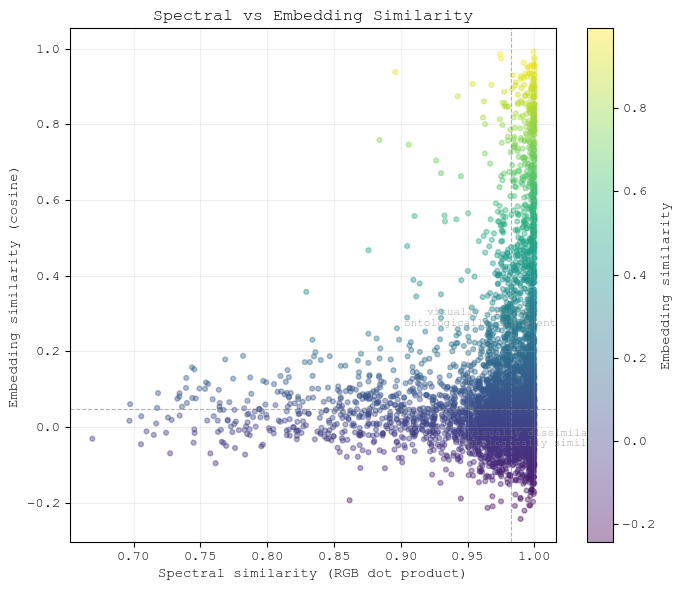

In [13]:
# ── scatter plot: spectral vs embedding similarity ─────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(spec_arr, emb_arr, alpha=0.4, s=12, c=emb_arr,
                cmap="viridis", vmin=emb_arr.min(), vmax=emb_arr.max())
plt.colorbar(sc, ax=ax, label="Embedding similarity")

# quadrant lines at the medians
ax.axvline(np.median(spec_arr), color="gray", lw=0.8, linestyle="--", alpha=0.6)
ax.axhline(np.median(emb_arr),  color="gray", lw=0.8, linestyle="--", alpha=0.6)

ax.set_xlabel("Spectral similarity (RGB dot product)")
ax.set_ylabel("Embedding similarity (cosine)")
ax.set_title("Spectral vs Embedding Similarity")
ax.grid(True, alpha=0.2)

# label quadrants
kw = dict(fontsize=8, color="gray", ha="center", va="center", alpha=0.7)
ax.text(np.percentile(spec_arr, 20), np.percentile(emb_arr, 85),
        "visually similar\nontologically different", **kw)
ax.text(np.percentile(spec_arr, 80), np.percentile(emb_arr, 15),
        "visually dissimilar\nontologically similar", **kw)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "spectral_vs_embedding_scatter.png"), dpi=150)
plt.show()

## Step 3: Find Outlier Pairs

We define outlier thresholds based on the distribution quartiles and find the best example of each outlier type.

In [14]:
# ── outlier thresholds ─────────────────────────────────────────────────────────
# "visually similar, ontologically different"  → high spec_sim, low emb_sim
# "visually dissimilar, ontologically similar" → low spec_sim,  high emb_sim

spec_hi = np.percentile(spec_arr, 75)
spec_lo = np.percentile(spec_arr, 25)
emb_hi  = np.percentile(emb_arr,  75)
emb_lo  = np.percentile(emb_arr,  25)

print(f"Thresholds — spec hi: {spec_hi:.3f}, spec lo: {spec_lo:.3f}")
print(f"            emb  hi: {emb_hi:.3f},  emb  lo: {emb_lo:.3f}\n")

# Score each pair: for TYPE A we want max(spec_sim) + min(emb_sim)
#                 for TYPE B we want min(spec_sim) + max(emb_sim)
# We use a combined "outlier score" = spec_sim - emb_sim  (TYPE A: large positive)
#                                   = emb_sim  - spec_sim (TYPE B: large positive)

score_A = spec_arr - emb_arr   # visually similar, ontologically different
score_B = emb_arr  - spec_arr  # visually dissimilar, ontologically similar

best_A_idx = int(np.argmax(score_A))
best_B_idx = int(np.argmax(score_B))

pair_A = results[best_A_idx]
pair_B = results[best_B_idx]

def print_pair(label, pair):
    print(f"── {label} ──")
    print(f"  Location 1: ({pair['lat_i']:.4f}, {pair['lon_i']:.4f})  [{pair['region_i']}]")
    print(f"              Land cover: {pair['lc_i']} (code {pair['class_i']})")
    print(f"  Location 2: ({pair['lat_j']:.4f}, {pair['lon_j']:.4f})  [{pair['region_j']}]")
    print(f"              Land cover: {pair['lc_j']} (code {pair['class_j']})")
    print(f"  Spectral sim (640 m mean RGB cosine): {pair['spec_sim']:.4f}")
    print(f"  Embedding sim (cosine)              : {pair['emb_sim']:.4f}")
    print()

print_pair("TYPE A — Spectrally Similar, Embedding Different", pair_A)
print_pair("TYPE B — Spectrally Different, Embedding Similar", pair_B)

Thresholds — spec hi: 0.996, spec lo: 0.966
            emb  hi: 0.151,  emb  lo: -0.005

── TYPE A — Spectrally Similar, Embedding Different ──
  Location 1: (-15.2305, -55.2156)  [South America]
              Land cover: Closed forest – unknown (code 116)
  Location 2: (11.4501, 0.0527)  [Western Africa]
              Land cover: Cropland (code 40)
  Spectral sim (640 m mean RGB cosine): 0.9897
  Embedding sim (cosine)              : -0.2427

── TYPE B — Spectrally Different, Embedding Similar ──
  Location 1: (36.4648, 28.8477)  [Unknown]
              Land cover: Ocean / no-data (code 0)
  Location 2: (11.4554, -62.6340)  [Unknown]
              Land cover: Ocean / no-data (code 0)
  Spectral sim (640 m mean RGB cosine): 0.8959
  Embedding sim (cosine)              : 0.9377



## Step 4: Save Images for Each Outlier Pair

For each pair we save four images into a labelled subdirectory:
- `loc1_satellite.png` — RGB satellite patch of location 1
- `loc2_satellite.png` — RGB satellite patch of location 2
- `loc1_embedding.png` — false-color embedding visualization of location 1 (dims 0–2 → RGB)
- `loc2_embedding.png` — false-color embedding visualization of location 2

In [15]:
# ── display config ─────────────────────────────────────────────────────────────
SAT_PATCH_PX  = 15     # half-size for TIF embedding patches (31×31 px @ 10 km = 310 km window)
SAT_BUFFER_M  = 5000   # half-width for larger GEE display image (10 km square)
SAT_IMG_PX    = 256    # output pixel size for large satellite images
SAT_YEAR      = 2024

_s2 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")

# ── Sentinel-2 large-context display image (10 km) ────────────────────────────
def get_rgb_patch_display(lat, lon,
                          buffer_m=SAT_BUFFER_M,
                          img_px=SAT_IMG_PX,
                          year=SAT_YEAR):
    """
    Fetch a larger (10 km) Sentinel-2 true-color patch for display.
    This is separate from the 640 m comparison patch in s2_cache.
    Returns (H, W, 3) uint8, or None on failure.
    """
    point  = ee.Geometry.Point(lon, lat)
    region = point.buffer(buffer_m).bounds()
    for cloud_thresh in [20, 50, 101]:
        try:
            col = (_s2
                   .filterDate(f"{year}-01-01", f"{year+1}-01-01")
                   .filterBounds(region))
            if cloud_thresh <= 100:
                col = col.filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", cloud_thresh))
            img = (col.median()
                      .select(["B4", "B3", "B2"])
                      .visualize(min=0, max=3000))
            url = img.getThumbURL({
                "region": region,
                "dimensions": f"{img_px}x{img_px}",
                "format": "png",
            })
            resp = requests.get(url, timeout=60)
            if resp.status_code == 200:
                return np.array(Image.open(BytesIO(resp.content)).convert("RGB"))
        except Exception:
            continue
    return None

# ── AlphaEarth false-color (first 3 embedding dims → R/G/B) ──────────────────
# The rgb_datasets TIFs contain AlphaEarth embedding dims 0/1/2 as R/G/B bands.
# Fixed global range [EMB_VMIN, EMB_VMAX] applied jointly to all bands —
# no per-band stretch — so colors are stable and spatially meaningful.
EMB_VMIN = -0.3
EMB_VMAX =  0.1

def get_emb_patch_display(lat, lon, patch_px=SAT_PATCH_PX):
    """
    Read a spatial window of the AlphaEarth TIF (bands 0–2 → R/G/B).
    Returns (H, W, 3) uint8 with consistent global normalization.
    """
    for ds in rgb_datasets:
        b = ds.bounds
        if b.left <= lon <= b.right and b.bottom <= lat <= b.top:
            row_r, col_r = ds.index(lon, lat)
            h, w = ds.shape
            r0 = max(0, row_r - patch_px);  c0 = max(0, col_r - patch_px)
            r1 = min(h, row_r + patch_px + 1);  c1 = min(w, col_r + patch_px + 1)
            win = rasterio.windows.Window(c0, r0, c1 - c0, r1 - r0)
            patch = ds.read(window=win).astype(np.float32)  # (3, H, W) = dims 0,1,2
            if np.isnan(patch).all():
                continue
            patch = np.nan_to_num(patch, nan=0.0)
            rgb = np.clip((patch - EMB_VMIN) / (EMB_VMAX - EMB_VMIN), 0, 1)
            return (np.moveaxis(rgb, 0, -1) * 255).astype(np.uint8)
    return None

# ── save individual images for a pair ─────────────────────────────────────────
def save_pair_images(pair, subdir_name):
    """
    Save four images per pair:
      loc1/2_comparison.png  — the actual 640 m S2 patch used in spectral comparison
      loc1/2_satellite.png   — larger 10 km true-color display image
      loc1/2_embedding.png   — AlphaEarth false-color (dims 0–2)
    """
    subdir = os.path.join(OUTPUT_DIR, subdir_name)
    os.makedirs(subdir, exist_ok=True)

    locs_info = [
        (pair["lat_i"], pair["lon_i"], pair["region_i"], pair["lc_i"], pair["i"], "loc1"),
        (pair["lat_j"], pair["lon_j"], pair["region_j"], pair["lc_j"], pair["j"], "loc2"),
    ]

    for lat, lon, region, lc_name, loc_i, fname_prefix in locs_info:
        # ── 640 m comparison patch (what spectral metric actually sees) ──
        cached = s2_cache.get(loc_i)
        fig, ax = plt.subplots(figsize=(3, 3))
        if cached is not None:
            ax.imshow(cached["img"])
        else:
            ax.set_facecolor("#cccccc")
            ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"640 m comparison patch\n{region}", fontsize=7)
        ax.axis("off")
        plt.tight_layout()
        plt.savefig(os.path.join(subdir, f"{fname_prefix}_comparison.png"), dpi=150, bbox_inches="tight")
        plt.close()

        # ── 10 km satellite display ──
        sat = get_rgb_patch_display(lat, lon)
        fig, ax = plt.subplots(figsize=(3, 3))
        if sat is not None:
            ax.imshow(sat)
        else:
            ax.set_facecolor("#cccccc")
            ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{region}\n({lat:.3f}, {lon:.3f})", fontsize=7)
        ax.axis("off")
        plt.tight_layout()
        plt.savefig(os.path.join(subdir, f"{fname_prefix}_satellite.png"), dpi=150, bbox_inches="tight")
        plt.close()

        # ── AlphaEarth false-color (dims 0–2) ──
        emb_patch = get_emb_patch_display(lat, lon)
        fig, ax = plt.subplots(figsize=(3, 3))
        if emb_patch is not None:
            ax.imshow(emb_patch)
        else:
            ax.set_facecolor("#555555")
            ax.text(0.5, 0.5, "no data", ha="center", va="center",
                    color="white", transform=ax.transAxes)
        ax.set_title(f"AlphaEarth dims 0–2\n{lc_name}", fontsize=7)
        ax.axis("off")
        plt.tight_layout()
        plt.savefig(os.path.join(subdir, f"{fname_prefix}_embedding.png"), dpi=150, bbox_inches="tight")
        plt.close()

        print(f"  {fname_prefix}: {region} — {lc_name}")

print("Display helpers ready.")
print(f"  Comparison patch : {SAT_CMP_PX}×{SAT_CMP_PX} px @ {SAT_CMP_SCALE} m/px = {SAT_CMP_PX*SAT_CMP_SCALE} m (mean RGB)")
print(f"  Display satellite: {SAT_BUFFER_M*2/1000:.0f} km window, {SAT_IMG_PX}px")
print(f"  Display embedding: AlphaEarth dims 0–2, {(2*SAT_PATCH_PX+1)*10:.0f} km, range [{EMB_VMIN}, {EMB_VMAX}]")

print("\nSaving images for TYPE A (spectrally similar, different embedding) …")
save_pair_images(pair_A, "type_A_similar_spectral_different_embedding")

print("\nSaving images for TYPE B (spectrally different, similar embedding) …")
save_pair_images(pair_B, "type_B_dissimilar_spectral_similar_embedding")

print("\nDone.")


Display helpers ready.
  Comparison patch : 64×64 px @ 10 m/px = 640 m (mean RGB)
  Display satellite: 10 km window, 256px
  Display embedding: AlphaEarth dims 0–2, 310 km, range [-0.3, 0.1]

Saving images for TYPE A (spectrally similar, different embedding) …
  loc1: South America — Closed forest – unknown
  loc2: Western Africa — Cropland

Saving images for TYPE B (spectrally different, similar embedding) …
  loc1: Unknown — Ocean / no-data
  loc2: Unknown — Ocean / no-data

Done.


## Step 5: Summary Panel

Display both pairs side-by-side: satellite patches and embedding false-colour tiles, with annotations showing the two similarity scores.

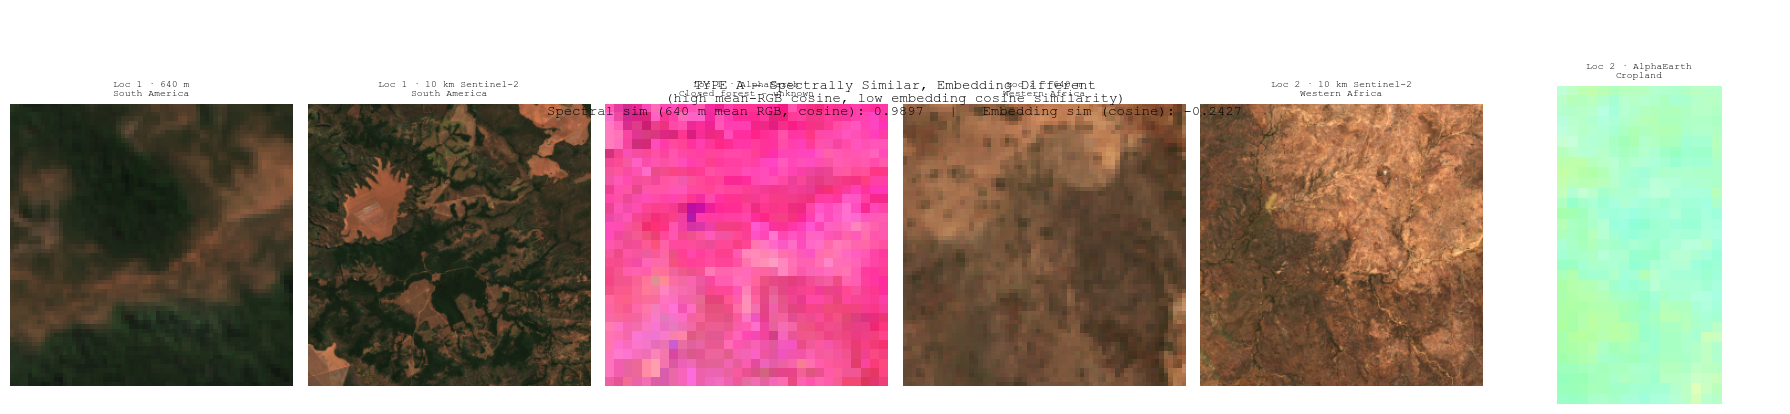

Saved: spectral_distance_output/summary_type_A.png


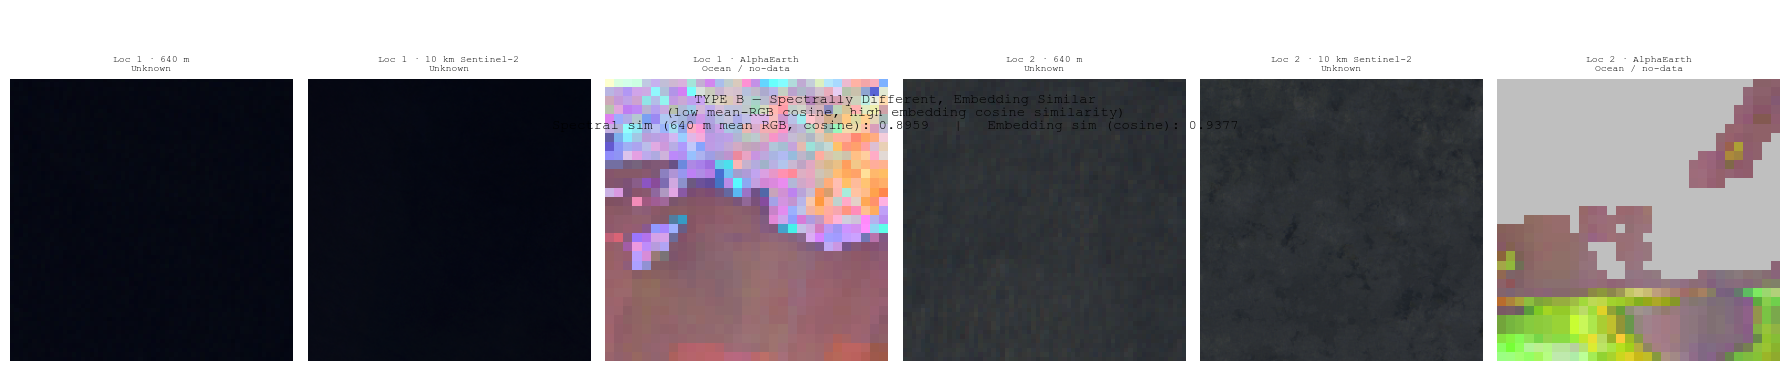

Saved: spectral_distance_output/summary_type_B.png


In [16]:
def make_summary_panel(pair, type_label, filename):
    """
    6-column figure:
      [loc1 640m patch | loc1 10km sat | loc1 AlphaEarth | loc2 640m | loc2 10km | loc2 AE]
    Header shows the pair type and both similarity scores.
    """
    cmp1 = s2_cache.get(pair["i"])
    cmp2 = s2_cache.get(pair["j"])
    sat1 = get_rgb_patch_display(pair["lat_i"], pair["lon_i"])
    sat2 = get_rgb_patch_display(pair["lat_j"], pair["lon_j"])
    emb1 = get_emb_patch_display(pair["lat_i"], pair["lon_i"])
    emb2 = get_emb_patch_display(pair["lat_j"], pair["lon_j"])

    fig, axes = plt.subplots(2, 6, figsize=(18, 5),
                             gridspec_kw={"height_ratios": [0.12, 1]})

    for ax in axes[0]:
        ax.axis("off")
    header_ax = fig.add_subplot(2, 1, 1)
    header_ax.axis("off")
    header_ax.set_zorder(10)
    header_ax.text(
        0.5, 0.5,
        f"{type_label}\n"
        f"Spectral sim (640 m mean RGB, cosine): {pair['spec_sim']:.4f}   |   "
        f"Embedding sim (cosine): {pair['emb_sim']:.4f}",
        ha="center", va="center", fontsize=10,
        transform=header_ax.transAxes,
    )

    images = [
        cmp1["img"] if cmp1 else None, sat1, emb1,
        cmp2["img"] if cmp2 else None, sat2, emb2,
    ]
    titles = [
        f"Loc 1 · 640 m\n{pair['region_i']}",
        f"Loc 1 · 10 km Sentinel-2\n{pair['region_i']}",
        f"Loc 1 · AlphaEarth\n{pair['lc_i']}",
        f"Loc 2 · 640 m\n{pair['region_j']}",
        f"Loc 2 · 10 km Sentinel-2\n{pair['region_j']}",
        f"Loc 2 · AlphaEarth\n{pair['lc_j']}",
    ]
    borders = ["#4a9eda", "#4a9eda", "#2d7a2d", "#d9534f", "#d9534f", "#e07c35"]

    for ax, img, title, color in zip(axes[1], images, titles, borders):
        if img is not None:
            ax.imshow(img)
        else:
            ax.set_facecolor("#cccccc")
        ax.set_title(title, fontsize=7)
        ax.axis("off")
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2)
            spine.set_visible(True)

    plt.tight_layout(rect=[0, 0, 1, 0.85])
    out_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")

make_summary_panel(
    pair_A,
    "TYPE A — Spectrally Similar, Embedding Different\n"
    "(high mean-RGB cosine, low embedding cosine similarity)",
    "summary_type_A.png",
)

make_summary_panel(
    pair_B,
    "TYPE B — Spectrally Different, Embedding Similar\n"
    "(low mean-RGB cosine, high embedding cosine similarity)",
    "summary_type_B.png",
)


## Step 6: Embedding Dimension Profiles

Plot the full 64-dimension embedding vectors for each location in both pairs. This shows *which* embedding dimensions drive the divergence or convergence that the cosine similarity number summarises.

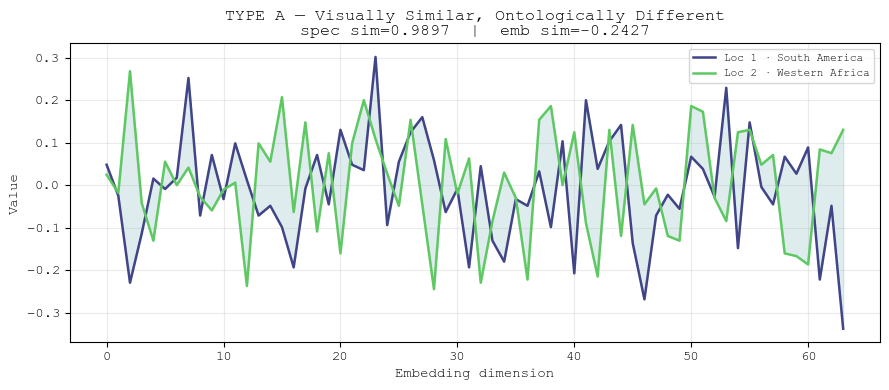

Saved: spectral_distance_output/embedding_profile_type_A.png


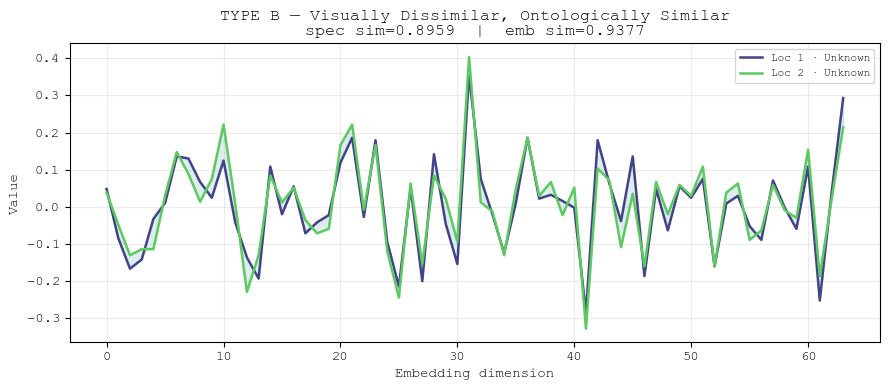

Saved: spectral_distance_output/embedding_profile_type_B.png


In [17]:
viridis = plt.cm.viridis
dims = np.arange(64)

def plot_embedding_profile(pair, type_label, filename):
    emb_i = locs.iloc[pair["i"]]["embedding"]
    emb_j = locs.iloc[pair["j"]]["embedding"]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(dims, emb_i, color=viridis(0.2), lw=1.8,
            label=f"Loc 1 · {pair['region_i']}")
    ax.plot(dims, emb_j, color=viridis(0.75), lw=1.8,
            label=f"Loc 2 · {pair['region_j']}")
    ax.fill_between(dims, emb_i, emb_j, alpha=0.15, color=viridis(0.45))

    ax.set_xlabel("Embedding dimension")
    ax.set_ylabel("Value")
    ax.set_title(
        f"{type_label}\n"
        f"spec sim={pair['spec_sim']:.4f}  |  emb sim={pair['emb_sim']:.4f}"
    )
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved: {out_path}")

plot_embedding_profile(pair_A, "TYPE A — Visually Similar, Ontologically Different",
                       "embedding_profile_type_A.png")
plot_embedding_profile(pair_B, "TYPE B — Visually Dissimilar, Ontologically Similar",
                       "embedding_profile_type_B.png")

## Step 7: Output File Summary

In [18]:
print(f"All outputs written to: {os.path.abspath(OUTPUT_DIR)}/\n")
for root, dirs, files in os.walk(OUTPUT_DIR):
    level = root.replace(OUTPUT_DIR, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in sorted(files):
        print(f"{indent}  {f}")

All outputs written to: /Users/emadsen/Documents/satellite-embeddings/distance-correlation/spectral_distance_output/

spectral_distance_output/
  embedding_profile_type_A.png
  embedding_profile_type_B.png
  spectral_vs_embedding_scatter.png
  summary_type_A.png
  summary_type_B.png
  type_B_dissimilar_spectral_similar_embedding/
    loc1_comparison.png
    loc1_embedding.png
    loc1_satellite.png
    loc2_comparison.png
    loc2_embedding.png
    loc2_satellite.png
  type_A_similar_spectral_different_embedding/
    loc1_comparison.png
    loc1_embedding.png
    loc1_satellite.png
    loc2_comparison.png
    loc2_embedding.png
    loc2_satellite.png
